# Options Lab — Black–Scholes Pricing, Greeks, Implied Volatility, and Monte Carlo

**Goal.** Implement core option pricing tools and validate them with consistency checks:
- Closed-form Black–Scholes prices (call/put)
- Greeks (Δ, Γ, Vega, Θ, Rho)
- Implied volatility inversion
- Monte Carlo pricing with variance reduction (antithetic + control variate)

We focus on correctness (parity checks, inversion tests) and numerical behavior (MC convergence).

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qmlab.bs import bs_price, bs_greeks, implied_vol, mc_price

# Base scenario (feel free to adjust later)
S, K, T = 100.0, 105.0, 0.5      # spot, strike, maturity in years
r, q = 0.02, 0.01                # risk-free rate, dividend yield
sigma = 0.25                     # volatility

## 1. Model assumptions (Black–Scholes)

Under the risk-neutral measure, the underlying follows:

\[
$dS_t = (r - q) S_t \, dt + \sigma S_t \, dW_t$
\]

where:
- \($r$\) is the risk-free rate,
- \($q$\) is the continuous dividend yield,
- \($\sigma$\) is constant volatility.

We price European options with maturity \($T$\) and strike \($K$\).

In [7]:
C = bs_price(S, K, T, r, sigma, option="call", q=q)
P = bs_price(S, K, T, r, sigma, option="put",  q=q)

pd.DataFrame({"Call (BS)": [C], "Put (BS)": [P]})

,Call (BS),Put (BS)
0,5.156028,9.610012


With \($S=100$\) and \($K=105$\) (slightly OTM call / ITM put), the put price exceeds the call price as expected. Dividend yield \($q>0$\) further decreases the call price and increases the put price (via forward adjustment).

## 2. Put–call parity (consistency check)

For European options with dividend yield \($q$\), put–call parity is:

\[
$C - P = S e^{-qT} - K e^{-rT}$
\]

A small absolute error indicates the pricing functions are consistent.

In [13]:
lhs = C - P
rhs = S * np.exp(-q * T) - K * np.exp(-r * T)

parity_tbl = pd.DataFrame({
    "lhs (C-P)": [lhs],
    "rhs (S e^{-qT} - K e^{-rT})": [rhs],
    "abs_error": [abs(lhs - rhs)],
})
parity_tbl.round(12)

,lhs (C-P),rhs (S e^{-qT} - K e^{-rT}),abs_error
0,-4.453985,-4.453985,0.0


**Put–call parity check.** The parity error is essentially zero (abs error ≈ 1e−14), confirming internal consistency of the call/put pricing implementation and correct handling of discounting and dividend yield.

## 3. Greeks (risk sensitivities)

We compute the standard Black–Scholes Greeks:
- **Delta (Δ):** sensitivity to spot
- **Gamma (Γ):** curvature vs spot
- **Vega:** sensitivity to volatility
- **Theta (Θ):** sensitivity to time (per year)
- **Rho:** sensitivity to rates

These provide a first-order view of hedging and risk.

In [14]:
greeks_call = bs_greeks(S, K, T, r, sigma, option="call", q=q)
greeks_put  = bs_greeks(S, K, T, r, sigma, option="put",  q=q)

greeks_tbl = pd.DataFrame({"call": greeks_call, "put": greeks_put})
greeks_tbl.round(6)

,call,put
delta,0.434528,-0.560485
gamma,0.022172,0.022172
vega,27.714774,27.714774
theta,-7.260101,-6.176009
rho,19.148379,-32.829238


**Units.** Vega is reported per +1.00 change in volatility (e.g., 0.25 → 1.25). For a +1% vol move, divide by 100. Theta is reported per year; to approximate per trading day, divide by 252.

**Greeks.** The signs and magnitudes match the option moneyness (S=100 < K=105). The call delta is below 0.5 while the put delta is below −0.5, and we observe the expected relationship Δ_call − Δ_put ≈ e^{−qT}. Gamma and vega are identical for call/put in Black–Scholes and are positive, reflecting convexity and volatility sensitivity. Theta is negative for both options, indicating time decay. Rho is positive for calls and negative for puts, consistent with rate discounting effects.

## 4. Implied volatility

Implied volatility (IV) is the value of ($\sigma$) that matches a market price:

\[
$\text{BS}(S,K,T,r,q,\sigma_{IV}) = \text{MarketPrice}$
\]

As a validation, if we input a BS price generated with ($\sigma$), the recovered IV should match \($\sigma$) (up to numerical tolerance).

In [15]:
iv = implied_vol(C, S, K, T, r, option="call", q=q)
iv_tbl = pd.DataFrame({"true_sigma": [sigma], "implied_vol": [iv], "abs_error": [abs(iv - sigma)]})
iv_tbl.round(12)

,true_sigma,implied_vol,abs_error
0,0.25,0.25,0.0


**Implied volatility validation.** Using a BS-generated call price as input, the implied volatility solver recovers the original volatility (σ=0.25) up to numerical precision (abs error ≈ 1e−14), validating the inversion routine and pricing monotonicity in σ.

## 5. Monte Carlo pricing and convergence

We simulate under the risk-neutral dynamics:

\[
$S_T = S \exp\Big((r-q-\tfrac12\sigma^2)T + \sigma\sqrt{T}\,Z\Big), \quad Z\sim\mathcal{N}(0,1)$
\]

We compare:
- **Plain MC**
- **Variance reduction (VR):** antithetic sampling + control variate

We expect VR to reduce error for the same number of paths.

In [16]:
ns = [2_000, 5_000, 10_000, 50_000, 200_000]
rows = []
for n in ns:
    mc_plain = mc_price(S, K, T, r, sigma, option="call", q=q,
                        n_paths=n, antithetic=False, control_variate=False, seed=0)
    mc_vr = mc_price(S, K, T, r, sigma, option="call", q=q,
                     n_paths=n, antithetic=True, control_variate=True, seed=0)

    rows.append({
        "n_paths": n,
        "bs_price": C,
        "mc_plain": mc_plain,
        "mc_vr": mc_vr,
        "abs_err_plain": abs(mc_plain - C),
        "abs_err_vr": abs(mc_vr - C),
    })

df_mc = pd.DataFrame(rows)
df_mc.round(6)

,n_paths,bs_price,mc_plain,mc_vr,abs_err_plain,abs_err_vr
0,2000,5.156028,4.928595,4.966927,0.227433,0.189101
1,5000,5.156028,5.159002,5.160793,0.002974,0.004765
2,10000,5.156028,5.200605,5.153505,0.044577,0.002523
3,50000,5.156028,5.175366,5.135409,0.019338,0.020619
4,200000,5.156028,5.163097,5.153766,0.007069,0.002261


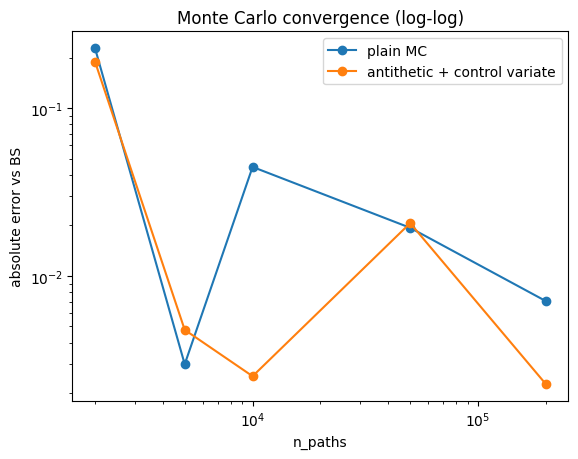

In [12]:
plt.figure()
plt.plot(df_mc["n_paths"], df_mc["abs_err_plain"], marker="o", label="plain MC")
plt.plot(df_mc["n_paths"], df_mc["abs_err_vr"], marker="o", label="antithetic + control variate")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("n_paths")
plt.ylabel("absolute error vs BS")
plt.title("Monte Carlo convergence (log-log)")
plt.legend()
plt.show()

### Monte Carlo convergence

We price the same European call via Monte Carlo under the risk-neutral dynamics and compare against the Black–Scholes benchmark (BS ≈ 5.1560). As the number of paths increases, both estimators converge toward the BS price, with typical Monte Carlo noise at small sample sizes.

Variance reduction (antithetic sampling + control variate) improves accuracy for several path counts. For example, at 10k paths the VR estimator achieves a much smaller absolute error than plain MC, and at 200k paths VR reduces the absolute error by roughly a factor of ~3. While the absolute error is not perfectly monotone in \(n\) (single-seed randomness), VR is expected to reduce variance on average.

## 6. Results

- **Closed-form pricing:** BS call/put prices are internally consistent (put–call parity error ≈ 1e−14).
- **Greeks:** the computed signs and magnitudes match the option moneyness (OTM call / ITM put). In particular, Δ_call − Δ_put ≈ e^{−qT}, and Γ/Vega are identical for call and put as expected in BS.
- **Implied volatility:** IV inversion recovers the original volatility σ=0.25 up to numerical precision (abs error ≈ 1e−14).
- **Monte Carlo:** both plain MC and variance-reduced MC converge toward the BS benchmark as the number of paths increases. Variance reduction (antithetic + control variate) often reduces error at fixed compute; for instance, at 200k paths the absolute error is roughly ~3× smaller than plain MC in this run.

## 7. Discussion & limitations

Put–call parity and IV inversion provide strong unit-level validation for the pricing implementation. Monte Carlo convergence illustrates the accuracy/compute trade-off and the practical value of variance reduction, while also showing the non-monotone behavior expected from single-run sampling noise. Limitations: Black–Scholes assumes constant volatility and lognormal dynamics; real markets exhibit smiles/skews, stochastic volatility, and jumps.

**One-line takeaway.** The BS pricer, Greeks, and IV solver pass strong consistency checks, and MC simulations converge toward BS with variance reduction improving accuracy for a given path budget.